In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px


In [2]:
path = os.path.expanduser("~/Desktop/UCSD/DS3/EnergyDS/Energy-Dashboard-DS3/IEA_Global_EV_Data_2024.csv")

# Load the data
ev_data = pd.read_csv(path)

# Quick look at the structure
print(ev_data.info())
display(ev_data.head())

<class 'pandas.DataFrame'>
RangeIndex: 12654 entries, 0 to 12653
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   region      12654 non-null  str    
 1   category    12654 non-null  str    
 2   parameter   12654 non-null  str    
 3   mode        12654 non-null  str    
 4   powertrain  12654 non-null  str    
 5   year        12654 non-null  int64  
 6   unit        12654 non-null  str    
 7   value       12654 non-null  float64
dtypes: float64(1), int64(1), str(6)
memory usage: 791.0 KB
None


,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV stock share,Cars,EV,2011,percent,0.00039
1,Australia,Historical,EV sales share,Cars,EV,2011,percent,0.00650
2,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.00000
3,Australia,Historical,EV stock,Cars,BEV,2011,Vehicles,49.00000
4,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,220.00000


In [3]:
## Make copy
# Renaming 'region' to 'country'
ev_data_3 = ev_data
ev_data_3 = ev_data.rename(columns={'region': 'country'})

# Verify the change
print(ev_data.columns)

Index(['region', 'category', 'parameter', 'mode', 'powertrain', 'year', 'unit',
       'value'],
      dtype='str')


In [4]:
# 1. Convert 'year' to datetime first to avoid the AttributeError
# We use unit='ns' because your data is currently in nanoseconds from 1970
ev_data_3['year'] = pd.to_datetime(ev_data_3['year'], unit='ns', errors='coerce')

# 2. Now extract the clean year as an integer
ev_data_3['year_clean'] = ev_data_3['year'].dt.year

# 3. Filter for Top 20 Countries, EV Sales only, and before 2025
aggregates = ['World', 'Europe', 'EU27', 'Rest of the world']
filtered_data = ev_data_3[
    (ev_data_3['parameter'] == 'EV sales') & 
    (~ev_data_3['country'].isin(aggregates)) & 
    (ev_data_3['year_clean'] < 2025)
]

# 4. Group, sort, and take the top 20
top_20_data = (filtered_data.groupby('country', as_index=False)['value']
               .sum()
               .sort_values(by='value', ascending=False)
               .head(20))

# 5. Plot
fig = px.bar(top_20_data, x='country', y='value', color='country',
            title="Top 20 Countries: Total EV Sales (Pre-2025)",
            labels={'country': "Country", 'value': 'Total Vehicles'})

fig.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='black', font=dict(color='white'))
fig.show()

/var/folders/gz/6c8jn9211fg0pdtxyqhhg3pw0000gn/T/ipykernel_56330/1187302004.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




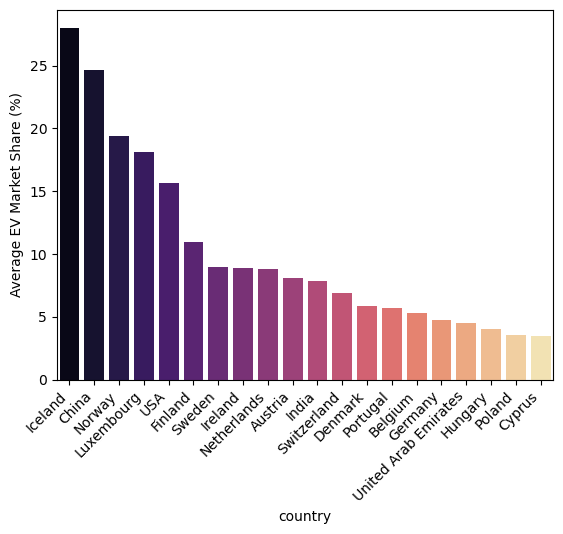

In [5]:
# Filter for 'EV sales share' instead of 'EV sales'
share_data = ev_data_3[
    (ev_data_3['parameter'] == 'EV sales share') & 
    (~ev_data_3['country'].isin(aggregates)) & 
    (ev_data_3['year_clean'] < 2025)
]

# We use .mean() because percentages shouldn't be summed across years
top_share_countries = (share_data.groupby('country')['value']
                       .mean()
                       .sort_values(ascending=False)
                       .head(20)
                       .reset_index())

# Plotting

sns.barplot(data=top_share_countries, x='country', y='value', palette="magma")

# Add this line to rotate the country names
plt.xticks(rotation=45, ha='right') 
plt.ylabel('Average EV Market Share (%)')
plt.show()

In [8]:
from pathlib import Path

out = Path("frontend/public/data")
out.mkdir(parents=True, exist_ok=True)

d3_df = top_share_countries.copy()
d3_df["value"] = d3_df["value"].astype(float)

d3_df.to_csv(out / "top_ev_sales_share_countries.csv", index=False)


In [9]:
print((out / "top_ev_sales_share_countries.csv").resolve())
print((out / "top_ev_sales_share_countries.csv").exists())
d3_df.head()


/Users/joshua/Desktop/UCSD/DS3/EnergyDS/Energy-Dashboard-DS3/Merge Folder/frontend/public/data/top_ev_sales_share_countries.csv
True


,country,value
0,Iceland,28.027500
1,China,24.618804
2,Norway,19.415390
3,Luxembourg,18.100000
4,USA,15.685943
